# Цель: провести EDA, проанализировать поведение зрителей, выявить факторы оттока и удержания зрителей на платформе.

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display, Markdown

path = kagglehub.dataset_download("sayeeduddin/netflix-2025user-behavior-dataset-210k-records")

print("Путь к скачанным файлам:", path)

Путь к скачанным файлам: C:\Users\proph\.cache\kagglehub\datasets\sayeeduddin\netflix-2025user-behavior-dataset-210k-records\versions\1


In [3]:
print(f'Содержимое папки: {os.listdir(path)}')

Содержимое папки: ['movies.csv', 'README.md', 'recommendation_logs.csv', 'reviews.csv', 'search_logs.csv', 'users.csv', 'watch_history.csv']


In [4]:
movies = pd.read_csv(os.path.join(path, 'movies.csv'))
print(f' Информация о фильмах\n количество строк: {movies.shape[0]},\n количество столбцов: {movies.shape[1]}\n\n')
movies.info()
movies.head(5)

 Информация о фильмах
 количество строк: 1040,
 количество столбцов: 18


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   movie_id             1040 non-null   object 
 1   title                1040 non-null   object 
 2   content_type         1040 non-null   object 
 3   genre_primary        1040 non-null   object 
 4   genre_secondary      373 non-null    object 
 5   release_year         1040 non-null   int64  
 6   duration_minutes     1040 non-null   float64
 7   rating               1040 non-null   object 
 8   language             1040 non-null   object 
 9   country_of_origin    1040 non-null   object 
 10  imdb_rating          890 non-null    float64
 11  production_budget    365 non-null    float64
 12  box_office_revenue   331 non-null    float64
 13  number_of_seasons    289 non-null    float64
 14  number_of_epis

,movie_id,title,content_type,genre_primary,genre_secondary,release_year,duration_minutes,rating,language,country_of_origin,imdb_rating,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning
0,movie_0001,Dragon Legend,Stand-up Comedy,History,Thriller,2014,35.0,TV-Y,French,Japan,NaN,NaN,NaN,NaN,NaN,False,2023-08-07,False
1,movie_0002,Storm Warrior,Stand-up Comedy,Sci-Fi,NaN,2017,37.0,PG,Japanese,USA,3.3,NaN,NaN,NaN,NaN,False,2022-01-28,True
2,movie_0003,Fire Family,Movie,Drama,NaN,2003,142.0,TV-MA,English,USA,8.5,2114120.0,NaN,NaN,NaN,False,2021-05-04,True
3,movie_0004,Our Princess,Documentary,Sci-Fi,NaN,2011,131.0,NC-17,Japanese,USA,5.3,NaN,NaN,NaN,NaN,False,2022-11-26,False
4,movie_0005,Warrior Mission,Documentary,Sport,Mystery,2015,91.0,TV-G,English,USA,3.1,NaN,NaN,NaN,NaN,False,2023-06-15,False


In [5]:
rec_logs = pd.read_csv(os.path.join(path, 'recommendation_logs.csv'))
print(f' Информация о рекомендациях\n количество строк: {rec_logs.shape[0]},\n количество столбцов: {rec_logs.shape[1]}\n\n')
rec_logs.info()
rec_logs.head(5)

 Информация о рекомендациях
 количество строк: 52000,
 количество столбцов: 11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recommendation_id     52000 non-null  object 
 1   user_id               52000 non-null  object 
 2   movie_id              52000 non-null  object 
 3   recommendation_date   52000 non-null  object 
 4   recommendation_type   52000 non-null  object 
 5   recommendation_score  46784 non-null  float64
 6   was_clicked           52000 non-null  bool   
 7   position_in_list      52000 non-null  int64  
 8   device_type           52000 non-null  object 
 9   time_of_day           52000 non-null  object 
 10  algorithm_version     49380 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 4.0+ MB


,recommendation_id,user_id,movie_id,recommendation_date,recommendation_type,recommendation_score,was_clicked,position_in_list,device_type,time_of_day,algorithm_version
0,rec_000001,user_06326,movie_0771,2025-07-03,new_releases,NaN,False,10,Tablet,evening,v1.4
1,rec_000002,user_02180,movie_0985,2024-11-07,genre_based,0.916,False,9,Mobile,evening,v1.4
2,rec_000003,user_03535,movie_0834,2024-08-22,personalized,0.816,False,2,Tablet,evening,v1.4
3,rec_000004,user_05025,movie_0718,2024-04-12,trending,0.771,False,16,Mobile,evening,v1.2
4,rec_000005,user_06794,movie_0718,2025-10-30,similar_users,0.251,False,9,Tablet,evening,v1.3


In [6]:
reviews = pd.read_csv(os.path.join(path, 'reviews.csv'))
print(f' Информация об отзывах\n количество строк: {reviews.shape[0]},\n количество столбцов: {reviews.shape[1]}\n\n')
reviews.info()
reviews.head(5)

 Информация об отзывах
 количество строк: 15450,
 количество столбцов: 12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15450 entries, 0 to 15449
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          15450 non-null  object 
 1   user_id            15450 non-null  object 
 2   movie_id           15450 non-null  object 
 3   rating             15450 non-null  int64  
 4   review_date        15450 non-null  object 
 5   device_type        15450 non-null  object 
 6   is_verified_watch  15450 non-null  bool   
 7   helpful_votes      13635 non-null  float64
 8   total_votes        13635 non-null  float64
 9   review_text        14665 non-null  object 
 10  sentiment          15450 non-null  object 
 11  sentiment_score    14241 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 1.3+ MB


,review_id,user_id,movie_id,rating,review_date,device_type,is_verified_watch,helpful_votes,total_votes,review_text,sentiment,sentiment_score
0,review_000001,user_07066,movie_0360,4,2025-03-29,Mobile,False,3.0,5.0,Fantastic cinematography and plot twists.,positive,0.711
1,review_000002,user_02953,movie_0095,5,2024-07-19,Mobile,True,2.0,2.0,This series is a masterpiece!,positive,0.645
2,review_000003,user_05528,movie_0518,4,2025-02-11,Tablet,True,2.0,5.0,Fantastic cinematography and plot twists.,positive,0.730
3,review_000004,user_07612,movie_0672,5,2025-11-26,Mobile,True,7.0,7.0,One of the best series I've ever watched. High...,positive,0.798
4,review_000005,user_03424,movie_0580,3,2025-07-11,Mobile,True,1.0,5.0,Mixed feelings about this one.,neutral,0.410


In [7]:
search = pd.read_csv(os.path.join(path, 'search_logs.csv'))
print(f' Информация о поисковых запросах\n количество строк: {search.shape[0]},\n количество столбцов: {search.shape[1]}\n\n')
search.info()
search.head(5)

 Информация о поисковых запросах
 количество строк: 26500,
 количество столбцов: 11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   search_id                26500 non-null  object 
 1   user_id                  26500 non-null  object 
 2   search_query             26500 non-null  object 
 3   search_date              26500 non-null  object 
 4   results_returned         26500 non-null  int64  
 5   clicked_result_position  12951 non-null  float64
 6   device_type              26500 non-null  object 
 7   search_duration_seconds  25223 non-null  float64
 8   had_typo                 26500 non-null  bool   
 9   used_filters             26500 non-null  bool   
 10  location_country         26500 non-null  object 
dtypes: bool(2), float64(2), int64(1), object(6)
memory usage: 1.9+ MB


,search_id,user_id,search_query,search_date,results_returned,clicked_result_position,device_type,search_duration_seconds,had_typo,used_filters,location_country
0,search_000001,user_09864,classic movies,2024-03-22,20,2.0,Tablet,12.4,False,False,Canada
1,search_000002,user_08038,stand up comedy,2025-11-22,24,4.0,Tablet,63.5,True,False,USA
2,search_000003,user_02009,music documentaries,2024-10-09,86,1.0,Tablet,24.7,True,False,USA
3,search_000004,user_01083,comedy shows,2024-12-14,70,4.0,Mobile,53.7,False,False,USA
4,search_000005,user_04269,movies based on true stories,2025-01-10,48,NaN,Tablet,69.6,True,False,USA


In [8]:
history = pd.read_csv(os.path.join(path, 'watch_history.csv'))
print(f' Информация об истории просмотра\n количество строк: {history.shape[0]},\n количество столбцов: {history.shape[1]}\n\n')
history.info()
history.head(5)

 Информация об истории просмотра
 количество строк: 105000,
 количество столбцов: 12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              105000 non-null  object 
 1   user_id                 105000 non-null  object 
 2   movie_id                105000 non-null  object 
 3   watch_date              105000 non-null  object 
 4   device_type             105000 non-null  object 
 5   watch_duration_minutes  92668 non-null   float64
 6   progress_percentage     96486 non-null   float64
 7   action                  105000 non-null  object 
 8   quality                 105000 non-null  object 
 9   location_country        105000 non-null  object 
 10  is_download             105000 non-null  bool   
 11  user_rating             21097 non-null   float64
dtypes: bool(1), float64(3), object(8)
memory 

,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,is_download,user_rating
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,False,NaN
1,session_000002,user_00861,movie_0588,2025-02-26,Laptop,120.1,44.2,started,HD,USA,False,NaN
2,session_000003,user_05391,movie_0694,2024-12-15,Desktop,572.1,84.7,started,HD,Canada,False,1.0
3,session_000004,user_05192,movie_0234,2024-09-30,Desktop,395.3,89.9,completed,SD,USA,False,5.0
4,session_000005,user_05735,movie_0390,2024-08-04,Tablet,14.6,6.2,completed,HD,USA,False,NaN


In [9]:
users = pd.read_csv(os.path.join(path, 'users.csv'))
print(f' Информация о пользователях\n количество строк: {users.shape[0]},\n количество столбцов: {users.shape[1]}\n\n')
users.info()

print(f"\nДубликаты: {users.duplicated().sum()}")
print(f"\nПропущенные значения:\n{users.isnull().sum()}")
print(users['is_active'].value_counts(normalize=True) * 100) 

 Информация о пользователях
 количество строк: 10300,
 количество столбцов: 16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10300 non-null  object 
 1   email                    10300 non-null  object 
 2   first_name               10300 non-null  object 
 3   last_name                10300 non-null  object 
 4   age                      9071 non-null   float64
 5   gender                   9476 non-null   object 
 6   country                  10300 non-null  object 
 7   state_province           10300 non-null  object 
 8   city                     10300 non-null  object 
 9   subscription_plan        10300 non-null  object 
 10  subscription_start_date  10300 non-null  object 
 11  is_active                10300 non-null  bool   
 12  monthly_spend            9283 non-null   float64


In [10]:
users.head(5)

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806


Ключевой столбец для нас - **is_active**, показывает отток пользователей. Также обратим внимание на **monthly_spend**, потому что нам нужно, чтобы пользователь смотрел контент дольше.

---

Далее очистим таблицу users от дубликатов и nulll`ов.



In [11]:
users_clean = users.drop_duplicates(subset=['user_id'], keep='first', ignore_index=False).copy()

print(f'Количество дубликатов в очищенной копии таблицы:\n{users_clean.duplicated().sum()}')

Количество дубликатов в очищенной копии таблицы:
0


Далее нужно заполнить null-значения. 

In [12]:
users_clean_subs = users_clean.groupby(['subscription_plan'])['age']

display(Markdown(f'**Распределение планов подписок по возрасту**'))
print(users_clean_subs.describe())

display(Markdown(f'<br>**Медианный возраст по подпискам:**'))
print(users_clean.groupby(['subscription_plan'])['age'].median())

**Распределение планов подписок по возрасту**

                    count       mean        std  min   25%   50%   75%    max
subscription_plan                                                            
Basic              1732.0  34.813510  12.743090 -5.0  26.0  34.0  43.0  109.0
Premium            3090.0  34.845955  12.300261 -5.0  27.0  35.0  43.0  104.0
Premium+            879.0  35.208191  13.350237 -5.0  27.0  35.0  42.0  109.0
Standard           3105.0  35.294364  12.499574 -7.0  27.0  35.0  44.0  107.0


<br>**Медианный возраст по подпискам:**

subscription_plan
Basic       34.0
Premium     35.0
Premium+    35.0
Standard    35.0
Name: age, dtype: float64


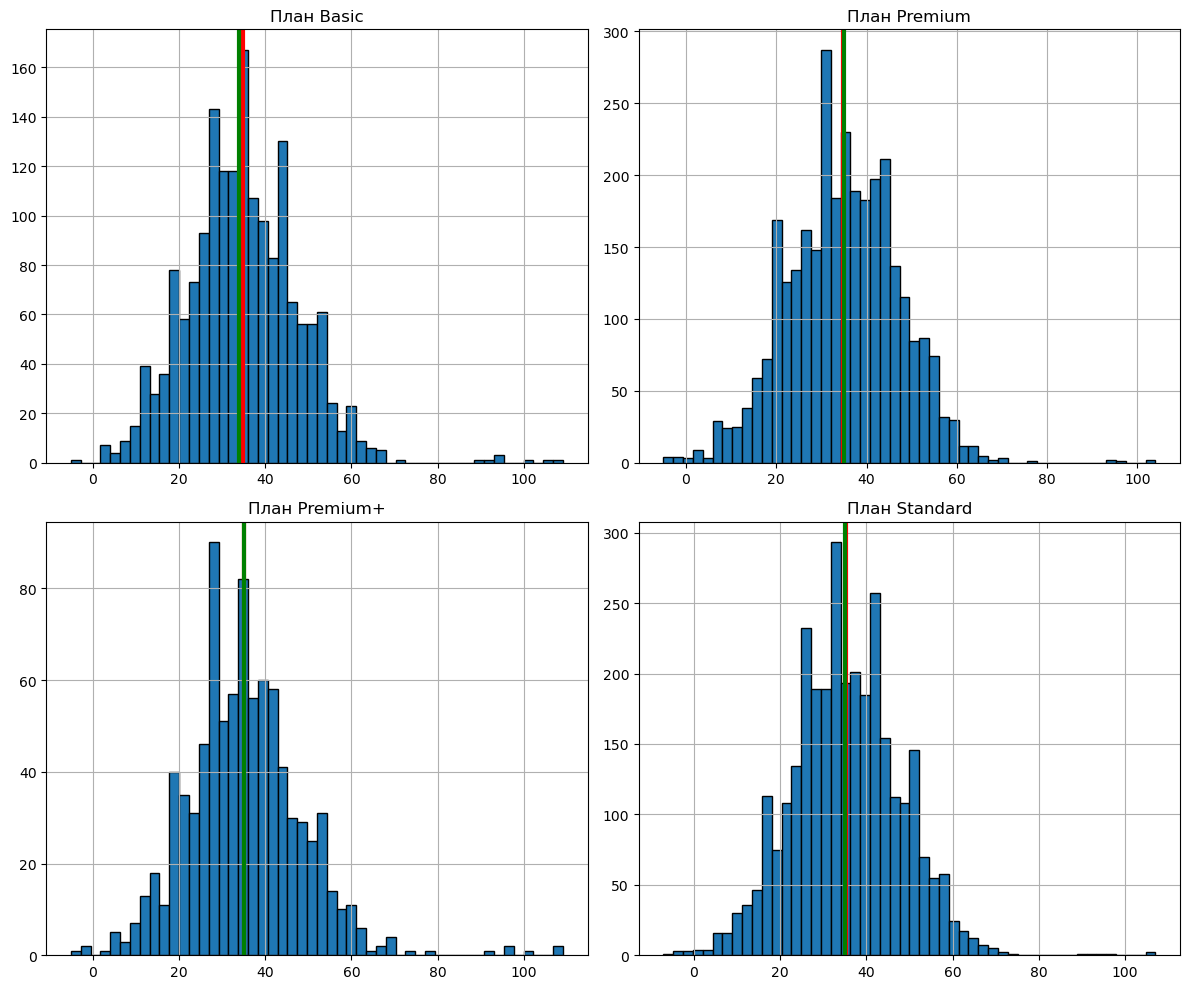

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = users_clean[users_clean['subscription_plan'] == 'Basic']['age'].hist(ax=axes[0, 0], bins=50, edgecolor='black', linewidth=1)
ax1.axvline(users_clean[users_clean['subscription_plan'] == 'Basic']['age'].mean(), color='red', linewidth=3)
ax1.axvline(users_clean[users_clean['subscription_plan'] == 'Basic']['age'].median(), color='green', linewidth=3)
ax1.set_title('План Basic')

ax2 = users_clean[users_clean['subscription_plan'] == 'Premium']['age'].hist(ax=axes[0, 1], bins=50, edgecolor='black', linewidth=1)
ax2.axvline(users_clean[users_clean['subscription_plan'] == 'Premium']['age'].mean(), color='red', linewidth=3)
ax2.axvline(users_clean[users_clean['subscription_plan'] == 'Premium']['age'].median(), color='green', linewidth=3)
ax2.set_title('План Premium')

ax3 = users_clean[users_clean['subscription_plan'] == 'Premium+']['age'].hist(ax=axes[1, 0], bins=50, edgecolor='black', linewidth=1)
ax3.axvline(users_clean[users_clean['subscription_plan'] == 'Premium+']['age'].mean(), color='red', linewidth=3)
ax3.axvline(users_clean[users_clean['subscription_plan'] == 'Premium+']['age'].median(), color='green', linewidth=3)
ax3.set_title('План Premium+')

ax4 = users_clean[users_clean['subscription_plan'] == 'Standard']['age'].hist(ax=axes[1, 1], bins=50, edgecolor='black', linewidth=1)
ax4.axvline(users_clean[users_clean['subscription_plan'] == 'Standard']['age'].mean(), color='red', linewidth=3)
ax4.axvline(users_clean[users_clean['subscription_plan'] == 'Standard']['age'].median(), color='green', linewidth=3)
ax4.set_title('План Standard')

plt.tight_layout()
plt.show()

Поскольку медианный возраст для всех подписок одинаковый, для заполнения null-значений в 'age' нам можно не ориентироваться на медианный возраст по подпискам, а просто взять общую медиану.

In [14]:
users_clean['age'] = users_clean['age'].fillna(users_clean['age'].median()).round(0)

In [15]:
users_clean['age'].info()

<class 'pandas.core.series.Series'>
Index: 10000 entries, 0 to 9999
Series name: age
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 156.2 KB


In [16]:
users_clean['gender'] = users_clean['gender'].fillna('Not filled')
users_clean['gender'].info()

<class 'pandas.core.series.Series'>
Index: 10000 entries, 0 to 9999
Series name: gender
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 156.2+ KB


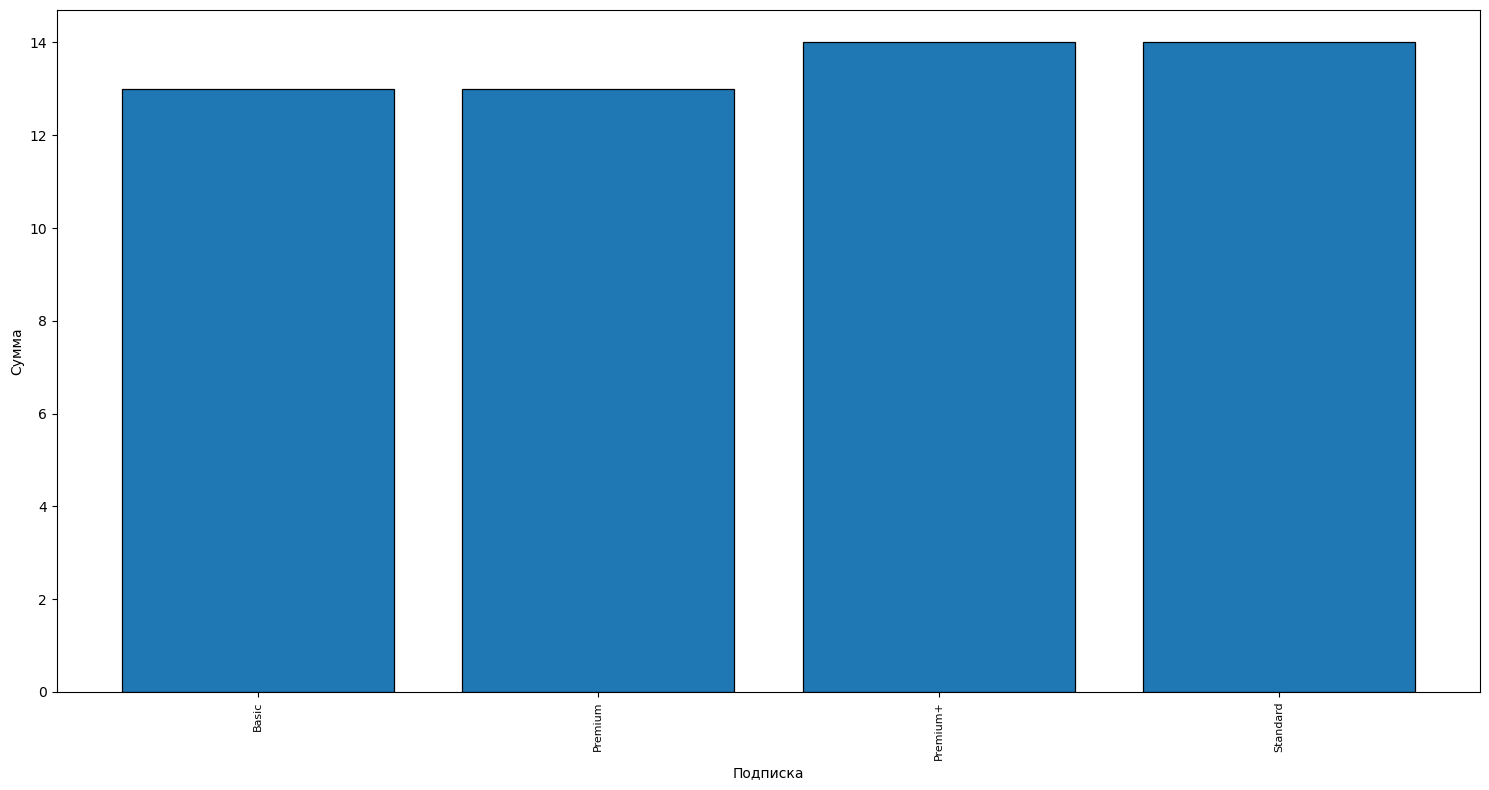

In [17]:
users_spent = users_clean.groupby(['subscription_plan'])['monthly_spend'].median().round(0)
plt.figure(figsize=(15, 8))
plt.bar(users_spent.index, users_spent.values, edgecolor='black', linewidth=0.9)
plt.xlabel('Подписка')
plt.ylabel('Сумма')

plt.xticks(ticks=users_spent.index, fontsize=8, rotation=90)
plt.tight_layout()
plt.show()


In [18]:
spent_median = users_spent.median()
print(spent_median)

13.5


In [19]:
users_clean['monthly_spend'] = users_clean.groupby('subscription_plan')['monthly_spend'].transform(lambda x: x.fillna(x.median()))
users_clean['monthly_spend'].info()

<class 'pandas.core.series.Series'>
Index: 10000 entries, 0 to 9999
Series name: monthly_spend
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 156.2 KB


In [20]:
print(f"\nПропущенные значения:\n{users_clean.isnull().sum()}")


Пропущенные значения:
user_id                       0
email                         0
first_name                    0
last_name                     0
age                           0
gender                        0
country                       0
state_province                0
city                          0
subscription_plan             0
subscription_start_date       0
is_active                     0
monthly_spend                 0
primary_device                0
household_size             1500
created_at                    0
dtype: int64


Так же заполняем пропуски в столбце "Размер домохозяйства":

In [21]:
users_clean['household_size'] = users_clean.groupby('country')['household_size'].transform(lambda x: x.fillna(x.median())) 
print(f"\nПропущенные значения:\n{users_clean.isnull().sum()}")


Пропущенные значения:
user_id                    0
email                      0
first_name                 0
last_name                  0
age                        0
gender                     0
country                    0
state_province             0
city                       0
subscription_plan          0
subscription_start_date    0
is_active                  0
monthly_spend              0
primary_device             0
household_size             0
created_at                 0
dtype: int64


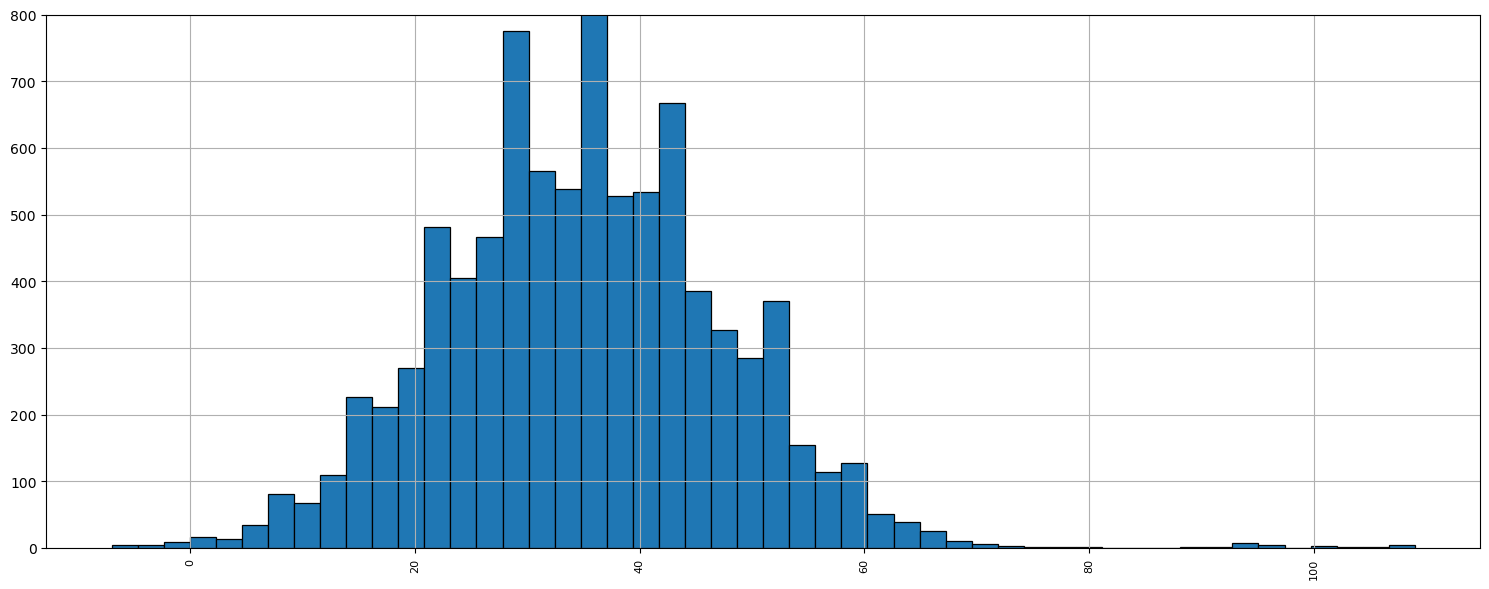

Строки с возрастом меньше нуля: 19


In [22]:
plt.figure(figsize=(15, 6))
users_clean['age'].hist(bins=50, edgecolor='black', linewidth=0.9)
plt.xticks(fontsize=8, rotation=90)
plt.ylim(0, 800)
plt.tight_layout()
plt.show()

print(f'Строки с возрастом меньше нуля: {users_clean[users_clean['age'] < 0]['age'].count()}')

In [23]:
users_minus_age = users_clean[users_clean['age'] < 0]
print(users_minus_age[['user_id', 'age', 'subscription_plan', 'monthly_spend', 'household_size']].reset_index().head(20))

    index     user_id  age subscription_plan  monthly_spend  household_size
0     527  user_00528 -1.0          Premium+          20.15             6.0
1    2189  user_02190 -2.0          Standard          13.84             2.0
2    3096  user_03097 -7.0          Standard          28.96             2.0
3    4671  user_04672 -2.0           Premium           6.37             2.0
4    4871  user_04872 -4.0          Standard           9.37             4.0
5    5942  user_05943 -3.0           Premium          24.71             6.0
6    5969  user_05970 -1.0           Premium           9.07             3.0
7    6191  user_06192 -4.0          Standard          13.84             4.0
8    6194  user_06195 -2.0          Standard          20.18             2.0
9    6333  user_06334 -3.0           Premium          41.75             1.0
10   6787  user_06788 -1.0           Premium           6.48             1.0
11   6895  user_06896 -4.0          Standard           2.27             1.0
12   7117  u

Видим, что строки с отрицательным возрастом действительно есть и это не ошибка знака (слишком маленькое значение по модулю).  
Можно заменить эти значения на медиану либо просто убрать (19 записей из 10000 не повлияют на статистику).  
Кроме этого, отфильтруем выборку по возрасту - оставим пользователей в возрасте от 15 до 80 лет.  
**15 лет** - потому что с этого возраста в США и Канаде (основа выборки) [можно работать](https://share.google/aimode/RvKpp9oqdx3K55oMF) можно работать и теоретически тратить доход на Netflix.  
**80 лет** - ожидаемая продолжительность жизни в США.

In [24]:
users_clean = users_clean[(users_clean['age'] >= 18) & (users_clean['age'] <= 80)]

users_clean.isnull().sum() # провереяем отсутствие пропусков

user_id                    0
email                      0
first_name                 0
last_name                  0
age                        0
gender                     0
country                    0
state_province             0
city                       0
subscription_plan          0
subscription_start_date    0
is_active                  0
monthly_spend              0
primary_device             0
household_size             0
created_at                 0
dtype: int64

---
#### Далее, исходя из поставленной цели, посмотрим таблицу **history** (бывш. _watch_history_), потому что в ней содержатся ключевые данные, характеризующие поведение зрителей: время сессии(просмотра), название фильма (можно подтянуть жанр), статус (досмотрел / не досмотрел), устройство.

In [25]:
display(Markdown('Ищем и удаляем дубликаты:'))
display(Markdown(f'<br>Количество дубликатов до очищения: **{history.duplicated().sum()}**<br>'))

history_clean = history.copy()
history_clean = history_clean.drop_duplicates()

display(Markdown(f'<br>Количество дубликатов после очищения: **{history_clean.duplicated().sum()}**<br>'))

Ищем и удаляем дубликаты:

<br>Количество дубликатов до очищения: **5000**<br>

<br>Количество дубликатов после очищения: **0**<br>

In [26]:
display(Markdown('Ищем пропуски:'))
history_clean.isnull().sum()

Ищем пропуски:

session_id                    0
user_id                       0
movie_id                      0
watch_date                    0
device_type                   0
watch_duration_minutes    11771
progress_percentage        8094
action                        0
quality                       0
location_country              0
is_download                   0
user_rating               79886
dtype: int64

Видим, что столбцы времени просмотра и прогресса просмотра содержат много пропусков. Причем непонятна природа этих пропусков. Предположим, что это просто ошибка сбора данных. Для этого посмотрим, есть ли строки, где в обоих столбцах пропуски - если есть, есть основания такие строки удалить или заполнить пропуски нулём.

In [27]:
history_clean[(history_clean['watch_duration_minutes'].isna()) & (history_clean['progress_percentage'].isna())
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 985 entries, 66 to 99979
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              985 non-null    object 
 1   user_id                 985 non-null    object 
 2   movie_id                985 non-null    object 
 3   watch_date              985 non-null    object 
 4   device_type             985 non-null    object 
 5   watch_duration_minutes  0 non-null      float64
 6   progress_percentage     0 non-null      float64
 7   action                  985 non-null    object 
 8   quality                 985 non-null    object 
 9   location_country        985 non-null    object 
 10  is_download             985 non-null    bool   
 11  user_rating             185 non-null    float64
dtypes: bool(1), float64(3), object(8)
memory usage: 93.3+ KB


Видим, что таких строк нет. Значит, наверняка, это ошибка сбора данных. Заполним пропуски в watch_duration_minutes. Можно просто заполнить медианным значением, но попробуем сгруппировать время посмотра по другим столбцам - будем искать столбец с наибольшим разбросом в значениях медианы.

In [28]:
print("Медиана по device_type:")
print(history_clean.groupby('device_type')['watch_duration_minutes'].median())

print("\nМедиана по quality:")
print(history_clean.groupby('quality')['watch_duration_minutes'].median())

print("\nМедиана по action:")
print(history_clean.groupby('action')['watch_duration_minutes'].median())

print("\nМедиана по is_download:")
print(history_clean.groupby('is_download')['watch_duration_minutes'].median())

Медиана по device_type:
device_type
Desktop     51.4
Laptop      51.6
Mobile      51.1
Smart TV    51.3
Tablet      50.8
Name: watch_duration_minutes, dtype: float64

Медиана по quality:
quality
4K          51.4
HD          51.1
SD          51.5
Ultra HD    51.3
Name: watch_duration_minutes, dtype: float64

Медиана по action:
action
completed    51.1
paused       51.3
started      51.6
stopped      51.0
Name: watch_duration_minutes, dtype: float64

Медиана по is_download:
is_download
False    51.2
True     51.5
Name: watch_duration_minutes, dtype: float64


Какой-то небольшой разброс в медиане есть только по типу устройства. Заполним пропуски медианными значениями оттуда.

In [29]:
history_clean['watch_duration_minutes'] = history_clean.groupby('device_type')['watch_duration_minutes'].transform(lambda x: x.fillna(x.median()))

print(f'Количество строк с пропусками по столбцу history clean: 0\n {history_clean['watch_duration_minutes'].isnull().sum() == 0}') # проверяем

Количество строк с пропусками по столбцу history clean: 0
 True


Точно так же работаем с progress_percentage. Группируем и ищем медиану:

In [30]:
print("Медиана по device_type:")
print(history_clean.groupby('device_type')['progress_percentage'].median())

print("\nМедиана по quality:")
print(history_clean.groupby('quality')['progress_percentage'].median())

print("\nМедиана по action:")
print(history_clean.groupby('action')['progress_percentage'].median())

print("\nМедиана по is_download:")
print(history_clean.groupby('is_download')['progress_percentage'].median())

Медиана по device_type:
device_type
Desktop     50.15
Laptop      49.80
Mobile      50.00
Smart TV    49.10
Tablet      50.30
Name: progress_percentage, dtype: float64

Медиана по quality:
quality
4K          49.7
HD          50.0
SD          49.3
Ultra HD    50.2
Name: progress_percentage, dtype: float64

Медиана по action:
action
completed    49.9
paused       50.2
started      49.5
stopped      49.8
Name: progress_percentage, dtype: float64

Медиана по is_download:
is_download
False    50.0
True     49.3
Name: progress_percentage, dtype: float64


Везде есть несущественный разброс. Заполним пропуски, как и в **watch_duration_minutes**, медианными значениями по *типу устройств*.

In [31]:
history_clean['progress_percentage'] = history_clean.groupby('device_type')['progress_percentage'].transform(lambda x: x.fillna(x.median()))

print(f'Количество строк с пропусками по столбцу progress percentage: 0\n{history_clean['progress_percentage'].isnull().sum() == 0}') # проверяем

Количество строк с пропусками по столбцу progress percentage: 0
True


Последний столбец с пропусками - **user_rating**, однако в нем очень много пропусков - заполнение медианой исказит реальное распределение значений.

In [32]:
print(f'Процент пропусков от общего количества строк в столбце user_rating:\
{(history_clean['user_rating'].isnull().sum() / len(history_clean['user_rating']) * 100).round(1)}%')

Процент пропусков от общего количества строк в столбце user_rating:79.9%


 В целом, этот столбец не несет критически важной информации, поэтому просто его не трогаем.

---
Дальше немного поработаем с остальными таблицами. Сначала **movies**:

In [33]:
print(movies.info())
print('\nКоличество пропусков:')
print(movies.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   movie_id             1040 non-null   object 
 1   title                1040 non-null   object 
 2   content_type         1040 non-null   object 
 3   genre_primary        1040 non-null   object 
 4   genre_secondary      373 non-null    object 
 5   release_year         1040 non-null   int64  
 6   duration_minutes     1040 non-null   float64
 7   rating               1040 non-null   object 
 8   language             1040 non-null   object 
 9   country_of_origin    1040 non-null   object 
 10  imdb_rating          890 non-null    float64
 11  production_budget    365 non-null    float64
 12  box_office_revenue   331 non-null    float64
 13  number_of_seasons    289 non-null    float64
 14  number_of_episodes   321 non-null    float64
 15  is_netflix_original  1040 non-null   b

Из таблицы movies не нужно все столбцы, возьмем только некоторые (**'movie_id', 'title', 'content_type', 'genre_primary',
                       'genre_secondary', 'release_year', 'duration_minutes', 'imdb_rating'**), удалим дубликаты и заполним пропуски.

In [34]:
movies_clean = movies[['movie_id', 'title', 'content_type', 'genre_primary',
                       'genre_secondary', 'release_year', 'duration_minutes', 'imdb_rating']].copy()

In [35]:
# заполняем пропуски в imdb_rating
movies_clean['imdb_rating'] = movies_clean['imdb_rating'].fillna(movies_clean['imdb_rating'].median())
# заполняем пропуски в genre_secondary
movies_clean['genre_secondary'] = movies_clean['genre_secondary'].fillna('Неизвестно')
# удаляем дубликаты
movies_clean = movies_clean.drop_duplicates()

In [36]:
display(Markdown('**Проверяем наличие пропусков:**'))
movies_clean.isnull().sum()

**Проверяем наличие пропусков:**

movie_id            0
title               0
content_type        0
genre_primary       0
genre_secondary     0
release_year        0
duration_minutes    0
imdb_rating         0
dtype: int64

---
Точно так же чистим таблицу с рекомендациями **rec_logs**:

In [37]:
rec_logs.info()
print('\nКоличество пропусков:')
print(rec_logs.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recommendation_id     52000 non-null  object 
 1   user_id               52000 non-null  object 
 2   movie_id              52000 non-null  object 
 3   recommendation_date   52000 non-null  object 
 4   recommendation_type   52000 non-null  object 
 5   recommendation_score  46784 non-null  float64
 6   was_clicked           52000 non-null  bool   
 7   position_in_list      52000 non-null  int64  
 8   device_type           52000 non-null  object 
 9   time_of_day           52000 non-null  object 
 10  algorithm_version     49380 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 4.0+ MB

Количество пропусков:
recommendation_id          0
user_id                    0
movie_id                   0
recommendation_date        0
recommendation_typ

In [38]:
print(f'Смотрим, какие значения есть в столбце "algorithm_version":\n {rec_logs['algorithm_version'].unique()}\n\
Заполняем пропуски в этом столбце нулями')

Смотрим, какие значения есть в столбце "algorithm_version":
 ['v1.4' 'v1.2' 'v1.3' 'v2.0' nan]
Заполняем пропуски в этом столбце нулями


In [39]:
# заполняем пропуски в recommendation_score
rec_logs_clean = rec_logs.copy()
rec_logs_clean['recommendation_score'] = rec_logs['recommendation_score'].fillna(rec_logs['recommendation_score'].median())
# заполняем пропуски в algorithm_version
rec_logs_clean['algorithm_version'] = rec_logs['algorithm_version'].fillna(0)
# удаляем дубликаты
rec_logs_clean = rec_logs_clean.drop_duplicates()

---
Чистим таблицу **search**:

In [40]:
search.info()
print('\nКоличество пропусков:')
print(search.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   search_id                26500 non-null  object 
 1   user_id                  26500 non-null  object 
 2   search_query             26500 non-null  object 
 3   search_date              26500 non-null  object 
 4   results_returned         26500 non-null  int64  
 5   clicked_result_position  12951 non-null  float64
 6   device_type              26500 non-null  object 
 7   search_duration_seconds  25223 non-null  float64
 8   had_typo                 26500 non-null  bool   
 9   used_filters             26500 non-null  bool   
 10  location_country         26500 non-null  object 
dtypes: bool(2), float64(2), int64(1), object(6)
memory usage: 1.9+ MB

Количество пропусков:
search_id                      0
user_id                        0
search_query                 

In [41]:
search_clean = search.copy()
# удаляем дубликаты
search_clean = search_clean.drop_duplicates()
# Т.к. в столбце clicked_result_position пропусков больше половины, удаляем этот столбец
search_clean = search_clean.drop('clicked_result_position', axis=1)
# Заполняем пропуски в search_duration_seconds
search_clean['search_duration_seconds'] = search_clean['search_duration_seconds'].fillna(search_clean['search_duration_seconds'].median())

---
Чистим таблицу **reviews**:

In [42]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15450 entries, 0 to 15449
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          15450 non-null  object 
 1   user_id            15450 non-null  object 
 2   movie_id           15450 non-null  object 
 3   rating             15450 non-null  int64  
 4   review_date        15450 non-null  object 
 5   device_type        15450 non-null  object 
 6   is_verified_watch  15450 non-null  bool   
 7   helpful_votes      13635 non-null  float64
 8   total_votes        13635 non-null  float64
 9   review_text        14665 non-null  object 
 10  sentiment          15450 non-null  object 
 11  sentiment_score    14241 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 1.3+ MB


In [43]:
reviews_clean = reviews.copy()
# убираем дубликаты
reviews_clean = reviews_clean.drop_duplicates()
# оставляем только некоторые, самые важные, столбцы
reviews_clean = reviews_clean[['review_id', 'user_id', 'movie_id', 'rating', 'review_date',
       'device_type']]

Далее пропишем _агрегаты_ для дальнейшего анализа по таблицам **history_clean**, **movies_clean** и **users_clean**.

In [44]:
history_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              100000 non-null  object 
 1   user_id                 100000 non-null  object 
 2   movie_id                100000 non-null  object 
 3   watch_date              100000 non-null  object 
 4   device_type             100000 non-null  object 
 5   watch_duration_minutes  100000 non-null  float64
 6   progress_percentage     100000 non-null  float64
 7   action                  100000 non-null  object 
 8   quality                 100000 non-null  object 
 9   location_country        100000 non-null  object 
 10  is_download             100000 non-null  bool   
 11  user_rating             20114 non-null   float64
dtypes: bool(1), float64(3), object(8)
memory usage: 9.3+ MB


In [45]:
history_clean_agg = history_clean.groupby('user_id').agg(
    total_hours_watched=('watch_duration_minutes', lambda x: x.sum() / 60), # время просмотра в часах
    avg_progress=('progress_percentage', 'mean'), # средний прогресс просмотра
    unigue_days=('watch_date', 'nunique'),    # активность зрителя в днях
    unique_sessions=('session_id', 'nunique'),  # активность в посещениях платформы
    unique_devices=('device_type', 'nunique') # число используемых девайсов
).reset_index()

Создадим функцию для нахождения самого часто встречающегося значения и применим ее для поиска наиболее **популярного устройства** для просмотра:

In [46]:
def get_favorite(val):
    return val.mode()[0] if not val.mode().empty else 'Нет информации'

fav_device = history_clean.groupby('user_id')['device_type'].agg(get_favorite).reset_index()
fav_device.columns = ['user_id', 'favorite_device']

Соединим таблицы history_clean и movies_clean для выявления предпочтений зрителей.

In [47]:
history_movie_merge = history_clean.merge(
    movies_clean[['movie_id', 'content_type', 'genre_primary', 'imdb_rating']], on='movie_id', how='left'
    )

In [48]:
# находим любим тип контента
user_fav_content = history_movie_merge.groupby('user_id')['content_type'].agg(get_favorite).reset_index()
user_fav_content.columns = ['user_id', 'favorite_content']
# находим любимый жанр
user_fav_genre = history_movie_merge.groupby('user_id')['genre_primary'].agg(get_favorite).reset_index()
user_fav_genre.columns = ['user_id', 'favorite_genre']

Соединяем агрегаты и новые таблицы в единый DataFrame:

In [49]:
df = users_clean.merge(history_clean_agg, on='user_id', how='left')
df = df.merge(fav_device, on='user_id', how='left')
df = df.merge(user_fav_content, on='user_id', how='left')
df = df.merge(user_fav_genre, on='user_id', how='left')

Проверяем отсутствие дубликатов и null-значений:

In [50]:
print(f'Количество дубликатов: {df.duplicated().sum()}')
print(f'Количество пропусков:\n{df.isnull().sum()}')

Количество дубликатов: 0
Количество пропусков:
user_id                    0
email                      0
first_name                 0
last_name                  0
age                        0
gender                     0
country                    0
state_province             0
city                       0
subscription_plan          0
subscription_start_date    0
is_active                  0
monthly_spend              0
primary_device             0
household_size             0
created_at                 0
total_hours_watched        0
avg_progress               0
unigue_days                0
unique_sessions            0
unique_devices             0
favorite_device            0
favorite_content           0
favorite_genre             0
dtype: int64


---
### Далее начинаем непосредственно анализ

Сначала посчитаем **коэффициент оттока** зрителей, построим графики для визуализации и попробуем понять, какие факторы влият на уход зрителей с платформы.

**Коэффициент оттока зрителей:** 0.17

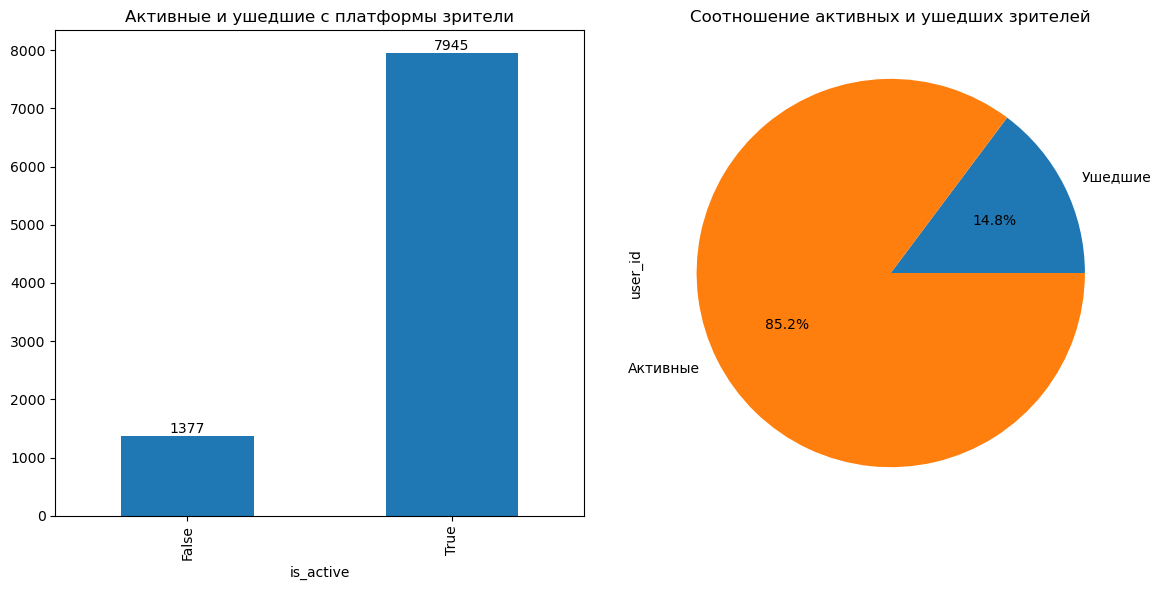

In [51]:
churn_rate = ((~df['is_active']).sum() / (df['is_active'].sum())).round(2)
display(Markdown(f'**Коэффициент оттока зрителей:** {churn_rate}'))

#построим графики
active_grouped = df.groupby('is_active')['user_id'].count()
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
#cтолбчатый график
plot = active_grouped.plot(kind='bar', ax=axes[0])
plot.bar_label(plot.containers[0], fmt='%.0f')
plot.set_title('Активные и ушедшие с платформы зрители')
#круговая диаграмма
pie = active_grouped.plot(kind='pie', autopct='%.1f%%', labels=['Ушедшие', 'Активные'], ax=axes[1])
pie.set_title('Соотношение активных и ушедших зрителей')

plt.tight_layout()
plt.show()

Рассмотрим отток зрителей в разрезе тарифных планов (подписок):

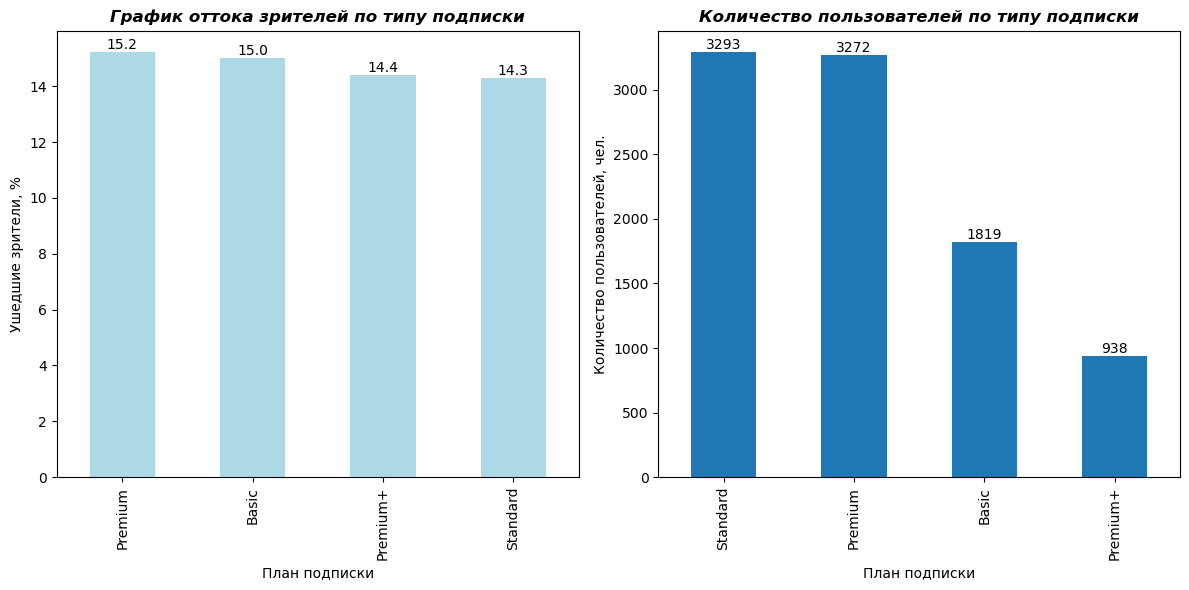

In [129]:
subscription_order = pd.CategoricalDtype(
    categories=['Basic', 'Standard', 'Premium', 'Premium+'],
    ordered=True
)
df['subscription_plan'] = df['subscription_plan'].astype(subscription_order)

churn_by_plan = ((~df['is_active']).groupby(df['subscription_plan'], observed=True).mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

bar = churn_by_plan.plot(kind='bar', color='lightblue', ax=axes[0])
bar.bar_label(bar.containers[0], fmt='%.1f')
bar.set_xlabel('План подписки')
bar.set_ylabel('Ушедшие зрители, %')
bar.set_title('График оттока зрителей по типу подписки', fontweight='bold', fontstyle='italic')

sub_users = df.groupby('subscription_plan', observed=True)['user_id'].count().sort_values(ascending=False)

plot = sub_users.plot(kind='bar', ax=axes[1])
plot.bar_label(plot.containers[0], fmt='%.0f')
plt.xlabel('План подписки')
plt.ylabel('Количество пользователей, чел.')
plt.title('Количество пользователей по типу подписки', fontweight='bold', fontstyle='italic')

plt.tight_layout()
plt.show()

Видим, что вне зависимости от типа подписки и количества пользователей, доля ушедших зрителей в среднем около 15%.
Т.е. дело точно не цене на подписку и не в "наполнении"/качестве подписки.  

Попробуем посмотреть на коэффициент оттока по возрастным группам.

In [117]:
df['age_group'] = pd.cut(df['age'], bins=[15, 25, 35, 45, 55, 65, 75, 80], labels=['15-25', '26-35', '36-45', '46-55', '56-65', '65-75', '75-80'])

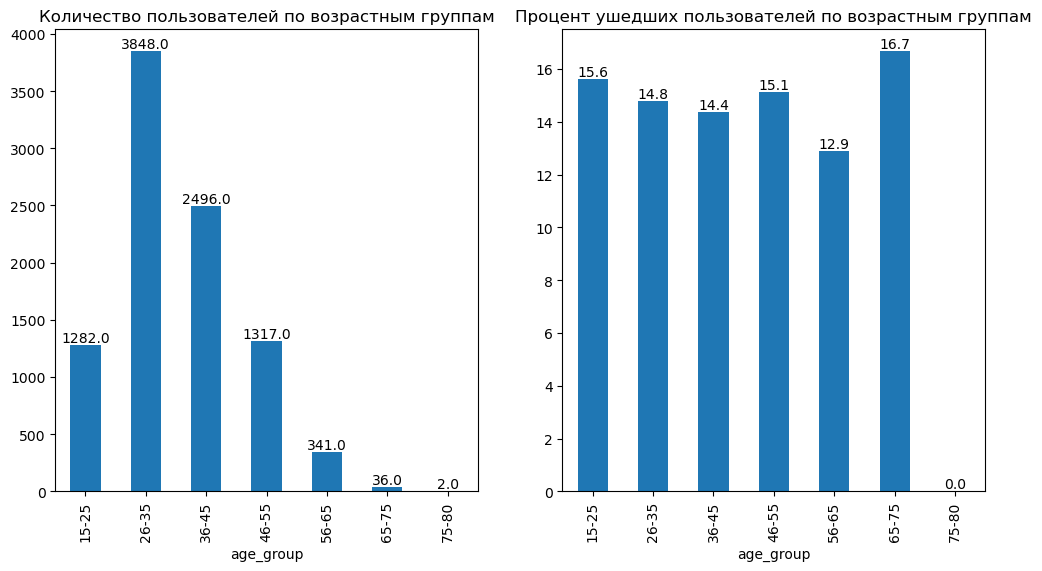

In [142]:
users_by_age = df.groupby('age_group', observed=True)['user_id'].count()
churn_by_age = ((~df['is_active']).groupby(df['age_group'], observed=True).mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot = users_by_age.plot(kind='bar', ax=axes[0])
plot.bar_label(plot.containers[0], fmt='%.1f')
plot.set_title('Количество пользователей по возрастным группам')

bar = churn_by_age.plot(kind='bar', ax = axes[1])
bar.bar_label(bar.containers[0], fmt='%.1f')
bar.set_title('Процент ушедших пользователей по возрастным группам')
plt.show()

После добавления возрастных групп видим, что наибольший отток наблюдается среди самой молодой группы **(15-25)** и, наоборот, самой возрастной **(65-75)**. 

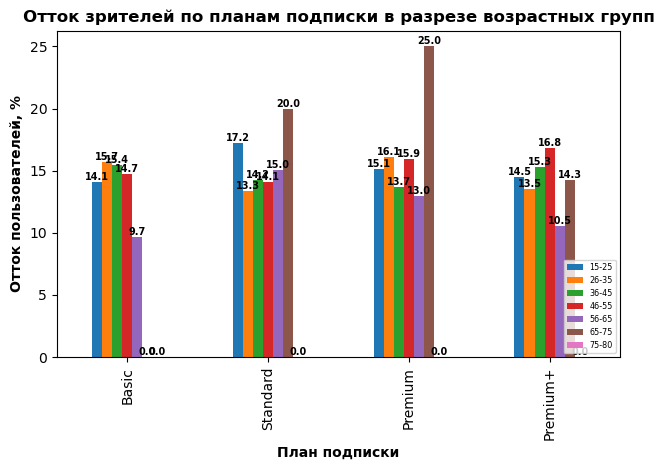

In [133]:
churn_by_sub_age = df.groupby(['subscription_plan', 'age_group'], observed= True)['is_active'].apply(lambda x: (1 - x.mean()) * 100).sort_values()

plot = churn_by_sub_age.unstack().plot(kind='bar')
for i in plot.containers: 
    plot.bar_label(i, fmt='%.1f', fontsize=7, fontweight='bold')

plt.xlabel('План подписки', fontweight='bold')
plt.ylabel('Отток пользователей, %', fontweight='bold')
plt.title('Отток зрителей по планам подписки в разрезе возрастных групп', fontweight='bold')
plt.tight_layout()
plt.legend(loc='lower right', fontsize='xx-small')
plt.show()